<a href="https://colab.research.google.com/github/LiviaMelgaco/teste04_IC_st/blob/main/simulacao_glarmaNEGBIN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Simulação de série por método de Monte Carlo
## Estimando parâmetros do GLARMA(1,0) com resposta Binomial Negativa (alpha = 5), comparando phi = 0.3 e phi = 0.8.


In [1]:
####### Simulação de Monte Carlo - GLARMA(1,0) Binomial Negativa #######
####### alpha = 5 -- Comparando phi = 0.3 e phi = 0.8            #######

RNGkind(kind = "Mersenne-Twister",
        normal.kind = "Inversion",
        sample.kind = "Rejection")


install.packages("pacman")
library("pacman")
pacman::p_load(glarma)

set.seed(222)


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependency ‘remotes’


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)


glarma installed



In [37]:
##### PARAMETROS #####

n     <- 200          # tamanho de cada série simulada

beta0 <- 1
beta1 <- 0.5
beta2 <- -0.1
phis  <- c(0.3, 0.8)   # cenários de phi a comparar

alpha <- 5             # parâmetro de dispersão da Binomial Negativa
# Parametrização NB2 (mesma do glarma/glm.nb): Var(Y | mu) = mu + mu^2 / alpha
# quanto MAIOR o alpha, mais perto da Poisson (menos dispersão)

Rs <- setNames(c(1000, 1000), as.character(phis))          #número de réplicas de Monte Carlo


In [38]:

##### FUNÇAO GERADORA GLARMA ######

## Função: gera UMA série GLARMA(1,0) com resposta Binomial Negativa e ajusta
# o modelo, devolvendo os coeficientes estimados (ou NA se não convergir)

simula_e_ajusta <- function(n, beta0, beta1, beta2, phi, alpha) {

  x1 <- rnorm(n, mean = 0, sd = 1)
  x2 <- rnorm(n, mean = 0, sd = 1)

  z   <- numeric(n)
  eta <- numeric(n)
  mu  <- numeric(n)
  y   <- numeric(n)
  e   <- numeric(n)

  z_ant <- 0
  e_ant <- 0

  for (t in 1:n) {
    z[t]   <- phi * (z_ant + e_ant)
    eta[t] <- beta0 + beta1 * x1[t] + beta2 * x2[t] + z[t]
    mu[t]  <- exp(eta[t])
    y[t]   <- rnbinom(1, mu = mu[t], size = alpha)
    e[t]   <- (y[t] - mu[t]) / sqrt(mu[t] + ((mu[t]^2) * alpha))  # resíduo de Pearson (NB2)

    z_ant <- z[t]
    e_ant <- e[t]
  }

  X_matriz <- cbind(intercept = 1, x1 = x1, x2 = x2)

  ajuste <- tryCatch(  #tryCatch se der erro, retorna NULL
    suppressWarnings(
      glarma(y, X_matriz,
             type      = "NegBin",
             method    = "FS",
             residuals = "Pearson",
             phiLags   = 1,
             alphaInit = alpha)  # valor inicial do alpha, ajuda na convergência
    ),
    error = function(cnd) NULL
  )

  # se o glarma não convergir/der erro para essa réplica, devolve NA
  if (is.null(ajuste)) {
    return(c(NA_real_, NA_real_, NA_real_, NA_real_, NA_real_))
  }

  coefs <- unlist(coef(ajuste)) #unlist() achata a lista preservando a ordem.

  if (length(coefs) != 5) {  #só garantindo que se der algo errado, vai virar NA tb
    return(c(NA_real_, NA_real_, NA_real_, NA_real_, NA_real_))
  }

  coefs <- as.numeric(coefs)

  coefs <- coefs[c(3, 4, 5, 1, 2)] # reordena: beta0, beta1, beta2, phi, alpha
  coefs


}


In [39]:
##### MONTE CARLO #####

resultados <- list()


for (phi_val in phis) {

  R_val <- Rs[[as.character(phi_val)]]  # número de réplicas DESSE phi

  cat("Rodando Monte Carlo para phi =", phi_val, "com R =", R_val, "réplicas\n")

  estimativas <- matrix(NA_real_, nrow = R_val, ncol = 5)
  colnames(estimativas) <- c("beta0", "beta1", "beta2", "phi", "alpha")

  for (r in 1:R_val) {
    estimativas[r, ] <- simula_e_ajusta(n, beta0, beta1, beta2, phi_val, alpha)
    if (r %% 500 == 0) cat("  réplica", r, "de", R_val, "\n") #tipo uma barra de progressão, a cada 500 réplicas
  }

  resultados[[as.character(phi_val)]] <- estimativas
}


Rodando Monte Carlo para phi = 0.3 com R = 1000 réplicas
  réplica 500 de 1000 
  réplica 1000 de 1000 
Rodando Monte Carlo para phi = 0.8 com R = 1000 réplicas
  réplica 500 de 1000 
  réplica 1000 de 1000 


In [40]:
##### EQM E MEDIAS #####

tabela_larga <- data.frame(parametro = c("beta0", "beta1", "beta2", "phi", "alpha"))

for (phi_val in phis) {

  R_val <- Rs[[as.character(phi_val)]]
  est   <- resultados[[as.character(phi_val)]]
  vt    <- c(beta0, beta1, beta2, phi_val, alpha)  # valor verdadeiro de cada parâmetro nesse cenário

  #filtrando as NA's do calculo e da tabela
  est_validas <- est[stats::complete.cases(est), , drop = FALSE]
  n_validas   <- nrow(est_validas)

  medias <- colMeans(est_validas)
  eqm    <- colMeans(sweep(est_validas, 2, vt, FUN = "-")^2)

  tabela_larga[[paste0("media_phi", phi_val)]] <- round(medias, 4)
  tabela_larga[[paste0("eqm_phi",   phi_val)]] <- round(eqm, 4)

  cat("phi =", phi_val, "->", n_validas, "de", R_val, "réplicas convergiram\n")
}


phi = 0.3 -> 1000 de 1000 réplicas convergiram
phi = 0.8 -> 1000 de 1000 réplicas convergiram


In [41]:
##### TABELA E GRAFICO FINAL #####

## tabela
cat("\nValores verdadeiros: beta0 =", beta0,
    ", beta1 =", beta1, ", beta2 =", beta2, ", alpha =", alpha, "\n\n")

print(tabela_larga)



Valores verdadeiros: beta0 = 1 , beta1 = 0.5 , beta2 = -0.1 , alpha = 5 

  parametro media_phi0.3 eqm_phi0.3 media_phi0.8 eqm_phi0.8
1     beta0       0.9965     0.0044       1.0353     0.0255
2     beta1       0.4995     0.0029       0.5051     0.0029
3     beta2      -0.0968     0.0029      -0.1022     0.0031
4       phi       0.0968     0.0444       0.3454     0.2135
5     alpha       5.9473     6.5243       4.1696     2.6605


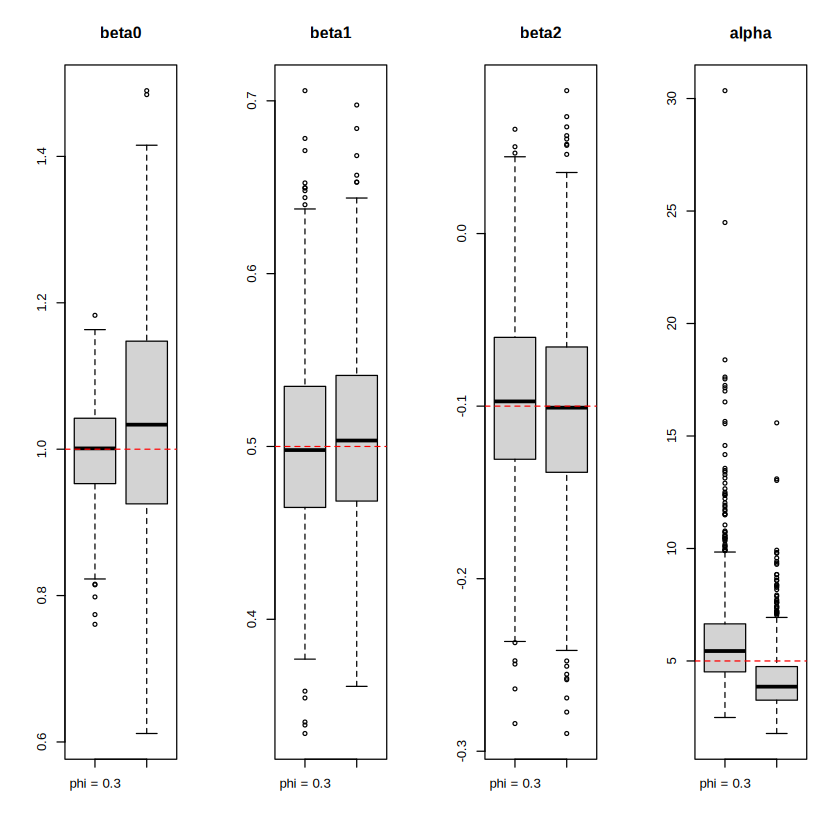

In [42]:
##boxplot (betas + alpha; phi é o eixo de comparação de cada painel)

par(mfrow = c(1, 4))
nomes_par <- c("beta0", "beta1", "beta2", "alpha")
valores_verdadeiros <- c(beta0, beta1, beta2, alpha)

for (i in seq_along(nomes_par)) {
  coluna <- nomes_par[i]
  boxplot(
    resultados[["0.3"]][, coluna], resultados[["0.8"]][, coluna],
    names = c("phi = 0.3", "phi = 0.8"),
    main = coluna
  )
  abline(h = valores_verdadeiros[i], col = "red", lty = 2)
}


In [43]:
writeLines(capture.output(sessionInfo()), "sessionInfo.txt")
